## Imports and Bootup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Encoding, Scaling, FeatureSelection 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from lightgbm import LGBMRegressor

# Models
from sklearn.model_selection import RandomizedSearchCV, KFold
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV

# Turning off warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATASET_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"

# Loading Datasets
train_data = pd.read_csv(DATASET_PATH + "/train.csv", low_memory=False)
test_data = pd.read_csv(DATASET_PATH + "/test.csv")

''' Train Data Has 50 Columns'''
train_data.shape,test_data.shape

((138701, 50), (15000, 49))

## 0. Constants

In [3]:
# CONSTANTS
RANDOM_STATE = 1551

# For Feature Selection
TOP_FEATURES = 30
TOP_FEATURES_STEP = 3
RSCV_N_ITER = 5


---

## 1. Naming Generic Columns

In [4]:
# Mapping (oldName: newName_oldName)
column_renames = {
    'col1': 'DriveSystem_col1',
    'col3': 'MachineSystem_col3',
    'col4': 'ExtensionArm_col4',
    'col5': 'EngineAspiration_col5',
    'col6': 'PrimaryExtension_col6',
    'col7': 'HorizontalWidth_col7',
    'col8': 'Shielding_col8',
    'col9': 'Power_col9',
    'col10': 'PowerSystem_col10',
    'col11': 'LoadBearingInterface_col11',
    'col12': 'PenetratingAcc_col12',
    'col13': 'SmoothingAcc_col13',
    'col14': 'ActuatorLogic_col14',
    'col15': 'TiresExt_col15',
    'col16': 'CouplingMech_col16',
    'col18': 'GroundSystem_col18',
    'col19': 'FluidRate_col19',
    'col20': 'SurfacePattern_col20',
    'col21': 'ContactWidth_col21',
    'col22': 'MaxArmLength_col22',
    'col23': 'RetainMaterialsInterface_col23',
    'col24': 'ControlConfig_col24',
    'col25': 'TractionComponent_col25',
    'col27': 'WorkTool_col27',
    'col28': 'SteeringConfig_col28',
    'col29': 'DifferentialPower_col29',
    'col30': 'SteeringInterface_col30'
}

In [5]:
# Before
print("Before: ", train_data.columns.tolist()[-1:], test_data.columns.tolist()[-1:], end="\t")

train_data.rename(columns=column_renames, inplace=True)
test_data.rename(columns=column_renames, inplace=True)  # Renaming columns in the test dataset to maintain consistency

# Print to verify the changes took place harmoniously
print("After:", train_data.columns.tolist()[-1:], test_data.columns.tolist()[-1:])

Before:  ['col30'] ['col30']	After: ['SteeringInterface_col30'] ['SteeringInterface_col30']


---

## 2. Existing dType Identification

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   TransactionID                   138701 non-null  int64  
 1   TargetValue                     138701 non-null  float64
 2   AssetID                         138701 non-null  int64  
 3   ProductConfigID                 138701 non-null  int64  
 4   DataOriginCode                  138701 non-null  object 
 5   VendorPartnerID                 138701 non-null  object 
 6   ManufactureYear                 138701 non-null  int64  
 7   OperationalHoursMeter           82058 non-null   float64
 8   UtilizationTier                 50475 non-null   object 
 9   TransactionDate                 138701 non-null  object 
 10  Spec_FullDescriptor             138701 non-null  object 
 11  Spec_BaseClass                  138701 non-null  object 
 12  Spec_SubClass   

In [7]:
# Printing DataTypes along with the Column names

d_types = train_data.dtypes

for i, d_type in enumerate( d_types.unique(), start=1):
    attrs = d_types[d_types == d_type].index.tolist()
    print(f"{i}. {d_type} ({len(attrs)}): {', '.join(attrs) if len(attrs) <= 10 else 'All Others : ' + ', '.join(attrs) }")   
    
    

1. int64 (4): TransactionID, AssetID, ProductConfigID, ManufactureYear
2. float64 (2): TargetValue, OperationalHoursMeter
3. object (44): All Others : DataOriginCode, VendorPartnerID, UtilizationTier, TransactionDate, Spec_FullDescriptor, Spec_BaseClass, Spec_SubClass, Spec_ReleaseSeries, Spec_VariantModifier, AssetScaleFactor, FunctionalClassification, RegionCode, InventoryGroupCategory, InventoryGroupDescription, DriveSystem_col1, CabinType, Forks, MachineSystem_col3, ExtensionArm_col4, DrivetrainType, EngineAspiration_col5, PrimaryExtension_col6, HorizontalWidth_col7, Shielding_col8, Power_col9, PowerSystem_col10, LoadBearingInterface_col11, PenetratingAcc_col12, SmoothingAcc_col13, ActuatorLogic_col14, TiresExt_col15, CouplingMech_col16, GroundSystem_col18, FluidRate_col19, SurfacePattern_col20, ContactWidth_col21, MaxArmLength_col22, RetainMaterialsInterface_col23, ControlConfig_col24, TractionComponent_col25, WorkTool_col27, SteeringConfig_col28, DifferentialPower_col29, Steering

---

## 3. Numerical Overview

In [8]:
# Numerical (n=6) Columns' Info

train_data.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


### <font color='Red'>-> Key points  <font/>
1. Target Value has +ve outlier(s) [Max > IQR]

2. Manufacture year has -ve outlier(s) [Min <<< IQR]

3. OperationalHoursMeter is Left Skewed and has +ve outlier(s)  [1st Quantile = Min; Max >> IQR]

---

## 4. Outliers
And imputing the original Numerical Columns

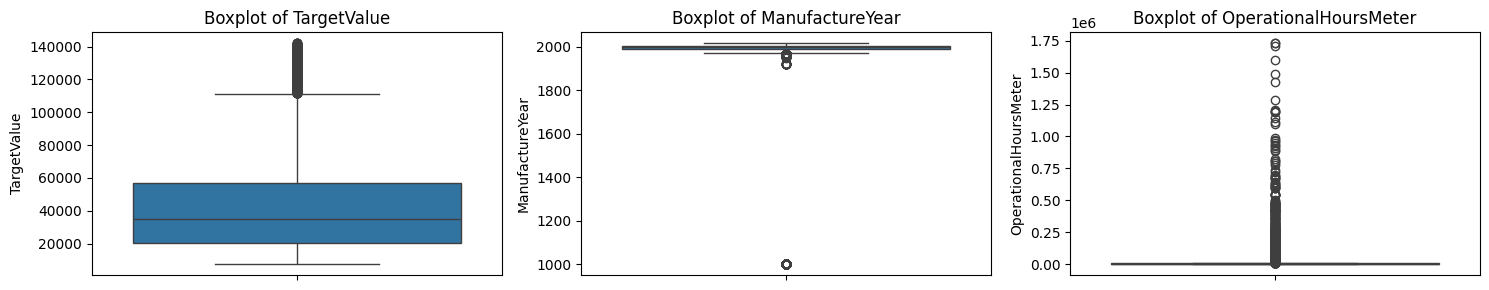

In [9]:
# Visualise to see better

# Not doing this for TransactionID, AssetID, ProductConfigID
# as they are just identifiers
plt.figure(figsize=(15, 3))

for i, col in enumerate(['TargetValue', 'ManufactureYear', 'OperationalHoursMeter'], start=1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=train_data[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### -> Data has Outliers

We'll deal with them as follows: 

1. **TargetValue** (Has +ve outliers)
We'll use __lop1p() transformation__ to squish them so they don't affect the training too much, plus it's risky to drop/cap the target value itself. The log transformation also allows us to use RMSE for our training, as the actual model evaluation uses RMSLE, which is what it'll effectively turn into.

2. **ManufactureYear** (has some -ve outliers and 1 dummy value 1001) 
We'll use binning to __categorise__ the data and mark 1001 as a different category :)


3. **OperationalHoursMeter** (has many +ve outliers and missing values too)
We'll add a missing value indicator column for this (__hasOperationalHours__) and retain the original data imputed with value 0 :)

### 1. TargetValue

In [ ]:
# Visualising need for change
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(train_data['TargetValue'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Original TargetValue Distribution')

sns.histplot(np.log1p(train_data['TargetValue']), bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Log1p Transformed TargetValue Distribution')

plt.tight_layout()
plt.show()

# Now Changing TargetValue

train_data['TargetValue'] = np.log1p(train_data['TargetValue'])

### 2. ManufactureYear

In [ ]:

# 2. ManufactureYear
train_data['ManufactureYear'] = train_data['ManufactureYear'].replace(1001, np.nan) # Replace 1001 with NaN

# Range now is (1920, 2015)
bins = [1919] + [1960 + 5*i for i in range(12)]
labels = ['1920-1960'] + [f"{1960 + 5*i}-{1965 + 5*i}" for i in range(11)]

# Cut into categorical bins and replace NaN (1001 values) with Unknown
train_data['ManufactureYear_Binned'] = pd.cut(train_data['ManufactureYear'], bins=bins, labels=labels, right=True)

train_data['ManufactureYear_Binned'] = train_data['ManufactureYear_Binned'].cat.add_categories('Unknown')
train_data['ManufactureYear_Binned'] = train_data['ManufactureYear_Binned'].fillna('Unknown')
train_data['ManufactureYear_Binned'] = train_data['ManufactureYear_Binned'].astype('str')

# We'll drop the col later

# Same for Test Data
test_data['ManufactureYear'] = test_data['ManufactureYear'].replace(1001, np.nan) # Replace 1001 with NaN
test_data['ManufactureYear_Binned'] = pd.cut(test_data['ManufactureYear'], bins=bins, labels=labels, right=True)
test_data['ManufactureYear_Binned'] = test_data['ManufactureYear_Binned'].cat.add_categories('Unknown')
test_data['ManufactureYear_Binned'] = test_data['ManufactureYear_Binned'].fillna('Unknown')
test_data['ManufactureYear_Binned'] = test_data['ManufactureYear_Binned'].astype('str')



### 3. OperationalHoursMeter

In [ ]:
# 3. OperationalHoursMeter
train_data['OperationalHoursMeter'] = train_data['OperationalHoursMeter'].fillna(0) # Imputation 
train_data['HasOperationalHours'] = (train_data['OperationalHoursMeter'] > 0).astype(int)

# For Test Data too
test_data['OperationalHoursMeter'] = test_data['OperationalHoursMeter'].fillna(0) # Imputation 
test_data['HasOperationalHours'] = (test_data['OperationalHoursMeter'] > 0).astype(int)


---

## 5. Sparsity Analysis

In [11]:
def get_sparsity_info():
    # Calculate missing counts and percentages
    missing_stats = train_data.isnull().sum().to_frame(name='Missing_Count')
    missing_stats['Missing_Percentage'] = (missing_stats['Missing_Count'] / len(train_data)) * 100


    # Filter for columns that have missing values and are categorical, sorted descending
    sparse_cols: pd.DataFrame = missing_stats[(missing_stats['Missing_Percentage'] > 0)].sort_values(by='Missing_Percentage', ascending=False)

    sparse_cols['Datatype'] = train_data[sparse_cols.index].dtypes.values
    sparse_cols['Unique_Values_Count'] = train_data[sparse_cols.index].nunique().values
    sparse_cols['Unique_Values'] = pd.Series(
        [
            ", ".join([str(val) for val in train_data[col].unique()]) if len(train_data[col].unique()) <= 10 else 'More than 10 Values' for col in sparse_cols.index
        ],
                                            index=sparse_cols.index)

    print(f"Total columns with missing values: {len(sparse_cols)}\n")
    display(sparse_cols.style.background_gradient(cmap='Reds'))

    return sparse_cols
    
sparse_cols = get_sparsity_info()


Total columns with missing values: 35



,Missing_Count,Missing_Percentage,Datatype,Unique_Values_Count,Unique_Values
GroundSystem_col18,138635,99.952416,object,2,"nan, None or Unspecified, Yes"
FluidRate_col19,138635,99.952416,object,2,"nan, Standard, High Flow"
ExtensionArm_col4,128320,92.515555,object,2,"nan, Extended, Standard"
EngineAspiration_col5,128320,92.515555,object,2,"nan, None or Unspecified, Yes"
SteeringConfig_col28,123742,89.214930,object,5,"nan, None or Unspecified, Differential Steer, Lever, Finger Tip, Pedal"
WorkTool_col27,123742,89.214930,object,9,"nan, None or Unspecified, PAT, Semi U, VPAT, Straight, Angle, U, Landfill, Coal"
SteeringInterface_col30,119829,86.393753,object,2,"Conventional, nan, Command Control"
DifferentialPower_col29,119829,86.393753,object,3,"Standard, nan, Limited Slip, No Spin"
ActuatorLogic_col14,115296,83.125572,object,3,"nan, Sideshift & Tip, None or Unspecified, Tip"
LoadBearingInterface_col11,115296,83.125572,object,2,"nan, None or Unspecified, Yes"


### Visualising Correlation of Categorical Variables

In [ ]:

def check_target_encoding_correlation(train_data, feature_col, target_col, verbose=True):
    # 1. Isolate the data and treat NaNs as a distinct category
    check_df = train_data[[feature_col, target_col]].copy()
    check_df[feature_col] = check_df[feature_col].fillna('Missing')

    # 3. MATHEMATICAL CHECK: Target Encoding Correlation
    # Calculate the mean TargetValue for each unique string
    category_means = check_df.groupby(feature_col)[target_col].mean()

    # Map these mathematical means back to the categories
    check_df['Series_Target_Encoded'] = check_df[feature_col].map(category_means)

    # Calculate Pearson correlation
    corr = check_df['Series_Target_Encoded'].corr(check_df[target_col])
    
    if verbose:
        print(f"Number of Unique Categories: {check_df[feature_col].nunique()}")
        print(f"Target Encoding Correlation: {corr:.4f}")
    
    return (check_df[feature_col].nunique(), round(corr, 4))
    
    
cat_cols = train_data.select_dtypes(include=['object', 'category']).columns.tolist() 

print("Remaining Numerical Columns:- \n", train_data.drop(cat_cols, axis=1).columns.tolist()) 

corr_data = []
for i, col in enumerate(cat_cols):

    (nUnique, corrVal) = check_target_encoding_correlation(train_data, col, 'TargetValue', verbose=False)

    corr_data.append({
        "Cat_Col_Name": col,
        "Num_Unique_Categories": nUnique,
        "Target_Encoding_Correlation": corrVal,
        "Unique_Values": ", ".join([str(val) for val in train_data[col].unique()]) if nUnique <= 10 else (", ".join([str(val) for val in train_data[col].unique()[:5]]) +'...')
    })

corr_df = pd.DataFrame(corr_data).sort_values(by='Num_Unique_Categories', ascending=False)
display(corr_df.style.background_gradient(cmap='Blues'))


---

## 6. Imputing 


-> We'll Impute the NaN values in Categorical Columns with '**None or Unspecified**' as it matches with the Dataset's native null-value-use.

* Imputation for Numerical Columns was done in the Outliers section itself :) [Only had OperationalHoursMeter]

In [12]:
for col in sparse_cols.index:
    train_data[col] = train_data[col].fillna('None or Unspecified')  
    
sparse_cols = get_sparsity_info()

Total columns with missing values: 0



,Missing_Count,Missing_Percentage,Datatype,Unique_Values_Count,Unique_Values


---

## 7. Adding Date Features + Scaling and Encoding


In [ ]:
# Extract Date Features and Calculate Age
def engineer_features(df):
    df_eng = df.copy()
    if 'TransactionDate' in df_eng.columns:
        df_eng['TransactionDate'] = pd.to_datetime(df_eng['TransactionDate'])
        df_eng['TransactionYear'] = df_eng['TransactionDate'].dt.year
        df_eng['TransactionMonth'] = df_eng['TransactionDate'].dt.month
        df_eng['TransactionDayDate'] = df_eng['TransactionDate'].dt.day
        
        df_eng = df_eng.drop(columns=['TransactionDate'])

    if 'ManufactureYear' in df_eng.columns:
        df_eng['ManufactureYear'] = pd.to_numeric(df_eng['ManufactureYear'], errors='coerce')
        
        # Calculate Age safely
        df_eng['EquipmentAge'] = df_eng['TransactionYear'] - df_eng['ManufactureYear']
        df_eng.loc[df_eng['EquipmentAge'] < 0, 'EquipmentAge'] = 0
        df_eng = df_eng.drop(columns=['ManufactureYear'])
                
    return df_eng

# Apply the fixed function
X_train_eng = engineer_features(train_data)
X_test_eng = engineer_features(test_data)

## Preprocessing

In [14]:
from sklearn.impute import SimpleImputer


# Drop IDs
drop_cols = ['TransactionID', 'AssetID', 'ProductConfigID', 'TargetValue'] 
X = X_train_eng.drop(columns=[col for col in drop_cols if col in X_train_eng.columns])
y = train_data['TargetValue'] # Already log1p transformed in Section 4!
X_test = X_test_eng.drop(columns=[col for col in drop_cols if col in X_test_eng.columns])

X_filtered = X
X_test_filtered = X_test

# Preprocessor
cat_cols = X_filtered.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_filtered.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='None or Unspecified')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_cols)
])

X_processed = preprocessor.fit_transform(X_filtered)
X_test_processed = preprocessor.transform(X_test_filtered)

print(f"Pre-Processing Complete, Shape: {X_processed.shape}")

Pre-Processing Complete, Shape: (138701, 49)


---

## 8. Models

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Max speed for submission
fast_models = {
    'LightGBM': LGBMRegressor(device='gpu', random_state=RANDOM_STATE, n_jobs=-1),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBRegressor(tree_method='hist', device='cuda', random_state=RANDOM_STATE, n_jobs=-1)
}

# Grids for HyperTuning
param_grids = {
    'LightGBM': {'n_estimators': [500,1000],
                'learning_rate': [0.03, 0.05, 0.1],
                'max_depth': [7,9,12],
                'min_child_weight': [1,3,5], 
                'subsample': [0.8,1],
                'colsample_bytree': [0.6, 0.8, 1]
                },
    'RandomForest': {'n_estimators': [30, 50], 'max_depth': [10, 15]},
    'XGBoost': {'n_estimators': [500,1000],
                'learning_rate': [0.03, 0.05, 0.1],
                'max_depth': [7,9,12],
                'min_child_weight': [1,3,5], 
                'subsample': [0.8,1],
                'colsample_bytree': [0.6, 0.8, 1]
                }
}

# =cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE) 
results = {}

def runRSCV():
    print("Running RandomizedSearchCV...")
    for name, model in fast_models.items():
        search = RandomizedSearchCV(
            estimator=model, param_distributions=param_grids[name],
            n_iter=10, cv=kf, scoring='neg_root_mean_squared_error',
            n_jobs=-1, random_state=RANDOM_STATE, verbose=4
        )
        search.fit(X_processed, y)
        results[name] = search
        print(f"Best Validation RMSE for {name}: {-search.best_score_:.4f}")

# runRSCV()

---

## 9. Final Model


In [ ]:
xgb = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.03, 
    max_depth=12, 
    min_child_weight=3, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=RANDOM_STATE, 
    tree_method='hist',
    device='cuda'
)
xgb.fit(X_processed, y)

lgbm = LGBMRegressor(
    n_estimators=1000, 
    learning_rate=0.03, 
    max_depth=12, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=RANDOM_STATE, 
    device='gpu',
    verbose=-1
)
lgbm.fit(X_processed, y)

xgb_preds = xgb.predict(X_test_processed)
lgbm_preds = lgbm.predict(X_test_processed)

# Averaging the predictions minimizes variance and secures your score!
blended_log_preds = (xgb_preds + lgbm_preds) / 2
final_predictions = np.expm1(blended_log_preds)

# Construct the exact submission format required
submission = pd.DataFrame({
    'TransactionID': test_data['TransactionID'],
    'TargetValue': final_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission saved successfully as 'submission.csv'! 🚀 Ready to submit!")

Submission saved successfully as 'submission.csv'! 🚀 Ready to submit!


---

# Thank You for your Time! 🙏😊